# PCA of sea level pressure fields (ERA5, Pacific)

This notebook continues `PCA_theory.ipynb`. There, PCA was applied to toy 2D points and to a small synthetic `xarray.Dataset`. Here the same `bluemath_tk` PCA is applied to a real climate dataset: **daily mean sea level pressure (msl) from ERA5 over the Pacific Ocean**.

The goal is the first step of a statistical downscaling workflow: to summarize the large-scale atmospheric circulation, which has thousands of grid points per day, with a small number of **principal components (PCs)**. Those daily PCs can later be used as predictors, for example of waves at a coastal site.

## Workflow

1. Open ERA5 msl, select 1979–2025 and average onto a 2° grid.
2. Explore the data: one day, and how it becomes a row of the PCA matrix.
3. Fit the PCA and choose the number of components.
4. Reconstruct a daily field from its PCs.
5. Interpret the spatial modes (EOFs).
6. Explore the temporal indices (PCs).
7. Compute the msl gradient with `spatial_gradient` and add it as a second predictor.

In [ ]:
import logging
import os
import warnings
warnings.filterwarnings("ignore")

# Hide bluemath_tk PCA log messages below ERROR
logging.getLogger("PCA").setLevel(logging.ERROR)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from bluemath_tk.core.operations import spatial_gradient
from bluemath_tk.datamining.pca import PCA

## 1. Load the ERA5 sea level pressure

The file contains daily ERA5 msl from 1940 onwards on a 0.25° grid covering 60°S–60°N and 100°E–290°E (70°W). That is roughly **46 GB**, far too much to load in memory. `xr.open_dataset` only reads the metadata, so it is safe to inspect the file first:

In [2]:
data_path = "../data/outputs"
msl_file = os.path.join(
    data_path, "era5_pacific_1940-01-01_to_2026-12-31_lat-60to60_lon100to290_msl.nc"
)

raw = xr.open_dataset(msl_file).rename(valid_time="time")
raw

<xarray.Dataset> Size: 46GB
Dimensions:    (time: 31655, latitude: 481, longitude: 761)
Coordinates:
  * time       (time) datetime64[ns] 253kB 1940-01-01 1940-01-02 ... 2026-08-31
  * latitude   (latitude) float64 4kB 60.0 59.75 59.5 ... -59.5 -59.75 -60.0
  * longitude  (longitude) float64 6kB 100.0 100.2 100.5 ... 289.5 289.8 290.0
Data variables:
    msl        (time, latitude, longitude) float32 46GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-19T08:43 GRIB to CDM+CF via cfgrib-0.9.1...

### Average onto a coarser grid

Large-scale circulation patterns can be represented on a coarser grid. We select **1979–2025** and use `coarsen(...).mean()` to average each **8 × 8 block** of the original 0.25° grid, giving a **2° grid**. This averages all values in each block rather than selecting every eighth point.

With `boundary="trim"`, incomplete blocks at the edges are discarded. The original 481 × 761 grid becomes **60 × 95 = 5,700 grid points**; the new coordinates are the block centers.

We read and average **one year at a time**, then save the reduced pressure in **Pa** to a dedicated cache file. On subsequent runs, this step reuses the cache. Conversion to **hPa** happens only in memory after loading, so rerunning the notebook does not repeatedly divide the saved values by 100.


In [3]:
years = range(1979, 2026)
coarsen_factor = 8  # Average 8 x 8 cells: 0.25° -> 2°
resolution = 0.25 * coarsen_factor

reduced_file = os.path.join(
    data_path,
    f"era5_pacific_msl_{years[0]}-{years[-1]}_{resolution:g}deg_blockmean_Pa.nc",
)

if not os.path.exists(reduced_file):
    yearly = []
    for year in years:
        msl_year = raw.msl.sel(time=str(year)).load()
        yearly.append(
            msl_year.coarsen(
                latitude=coarsen_factor,
                longitude=coarsen_factor,
                boundary="trim",
            ).mean(keep_attrs=True)
        )
    reduced = xr.concat(yearly, dim="time")
    reduced.attrs["units"] = "Pa"
    reduced.to_dataset(name="msl").to_netcdf(reduced_file)
    del yearly, msl_year, reduced


In [4]:
# Load the small cache, close the file, and convert Pa -> hPa in memory.
with xr.open_dataset(reduced_file) as reduced:
    msl = (reduced.msl.load() / 100).transpose("time", "latitude", "longitude")
msl.attrs.update(long_name="Mean sea level pressure", units="hPa")
msl

<xarray.DataArray 'msl' (time: 17167, latitude: 60, longitude: 95)> Size: 391MB
array([[[1007.7725 , 1005.6225 , 1003.705  , ..., 1023.6987 ,
         1023.16376, 1021.9    ],
        [1006.65625, 1005.71   , 1004.9875 , ..., 1025.53   ,
         1025.3037 , 1024.2725 ],
        [1006.6362 , 1007.41626, 1007.5725 , ..., 1025.6025 ,
         1024.9425 , 1023.5675 ],
        ...,
        [ 989.8075 ,  989.3237 ,  989.20374, ..., 1014.595  ,
         1014.02124, 1013.15625],
        [ 993.27374,  992.65   ,  992.17377, ..., 1011.705  ,
         1011.47876, 1010.9938 ],
        [ 995.8638 ,  995.09125,  994.53125, ..., 1008.165  ,
         1008.3825 , 1008.265  ]],

       [[1025.9812 , 1025.1863 , 1023.9487 , ..., 1014.7075 ,
         1015.46875, 1015.59125],
        [1024.0713 , 1022.47125, 1020.6788 , ..., 1013.6287 ,
         1014.08   , 1014.6275 ],
        [1022.33124, 1020.1625 , 1017.3738 , ..., 1012.8088 ,
         1012.12   , 1011.42   ],
...
        [ 981.39874,  981.28125,  981.515  , ...,  991.0513 ,
          990.9675 ,  991.0625 ],
        [ 972.96   ,  972.6887 ,  972.875  , ...,  989.2463 ,
          988.98627,  988.8713 ],
        [ 969.775  ,  969.2475 ,  969.04376, ...,  987.0563 ,
          986.91125,  986.8875 ]],

       [[1016.6138 , 1017.9    , 1018.9988 , ...,  968.74   ,
          970.15   ,  972.615  ],
        [1021.0625 , 1022.7775 , 1024.0162 , ...,  963.33   ,
          965.39   ,  968.3175 ],
        [1024.5825 , 1026.7775 , 1028.6125 , ...,  967.115  ,
          967.82874,  969.795  ],
        ...,
        [ 984.465  ,  984.2275 ,  984.04   , ..., 1007.0525 ,
         1006.6375 , 1005.8325 ],
        [ 978.73627,  978.3212 ,  978.0175 , ..., 1002.4975 ,
         1002.14   , 1001.5475 ],
        [ 975.9888 ,  975.23126,  974.515  , ...,  998.4975 ,
          998.33   ,  997.9425 ]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
  * latitude   (latitude) float64 480B 59.12 57.12 55.12 ... -56.88 -58.88
  * longitude  (longitude) float64 760B 100.9 102.9 104.9 ... 284.9 286.9 288.9
Attributes: (12/32)
    GRIB_paramId:                             151
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa
    long_name:                                Mean sea level pressure
    units:                                    hPa
    standard_name:                            air_pressure_at_mean_sea_level
    last_ingested_valid_time_index:           31654

## 2. Explore the data

Each day is a full pressure map. Comparing the original 0.25° field with the 2° version shows that the large-scale structure (subtropical highs, the Aleutian low, extratropical storms) is kept.

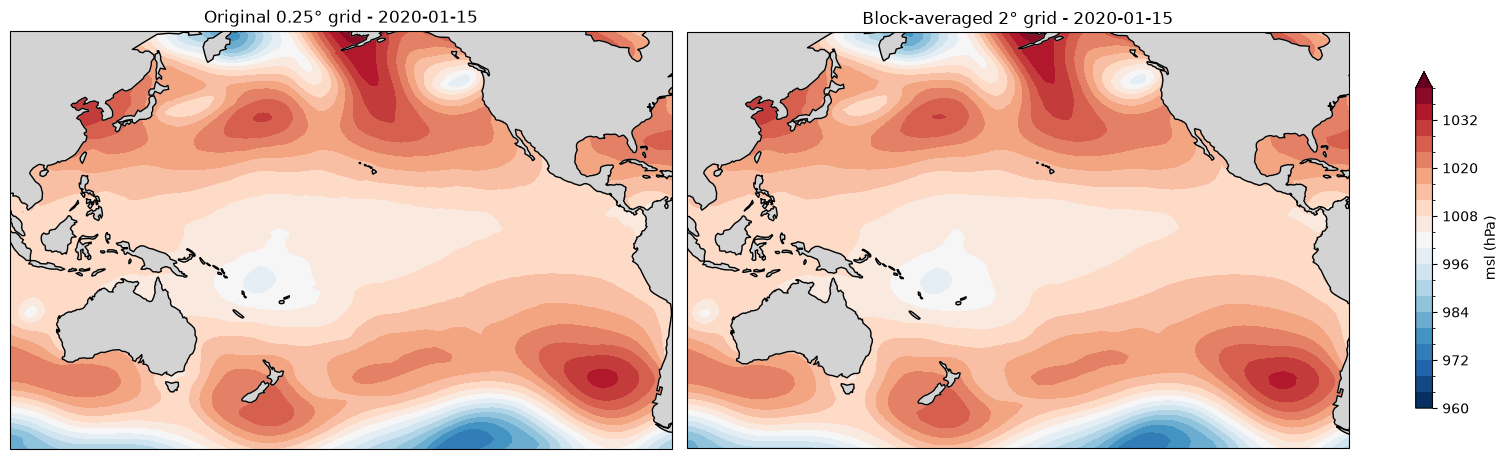

In [5]:
date = "2020-01-15"
proj = ccrs.PlateCarree(central_longitude=180)
levels = np.arange(960, 1041, 4)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), subplot_kw={"projection": proj}, layout="constrained")
for ax, field, title in zip(
    axes,
    [raw.msl.sel(time=date) / 100, msl.sel(time=date)],
    ["Original 0.25° grid", f"Block-averaged {resolution:g}° grid"],
):
    cf = field.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=levels, cmap="RdBu_r", add_colorbar=False)
    ax.add_feature(cfeature.LAND, color="lightgrey", zorder=2)
    ax.coastlines(zorder=3)
    ax.set_title(f"{title} - {date}")
fig.colorbar(cf, ax=axes, shrink=0.8, label="msl (hPa)");

As in `PCA_theory.ipynb`, the data are a **3D block** (`time` × `latitude` × `longitude`), and PCA needs a 2D matrix. Each daily map is flattened into one row, so `time` gives the observations and every grid point is a feature:

In [6]:
n_times, n_lat, n_lon = msl.shape
print(f"{n_times} days x ({n_lat} lat x {n_lon} lon) -> PCA matrix of {n_times} rows x {n_lat * n_lon} columns")

17167 days x (60 lat x 95 lon) -> PCA matrix of 17167 rows x 5700 columns


## 3. Fit the PCA

The call is the same as in the theory notebook:

- `vars_to_stack=["msl"]`: the variable used as predictor.
- `coords_to_stack=["latitude", "longitude"]`: every grid point becomes a feature (column).
- `pca_dim_for_rows="time"`: every day becomes an observation (row).
- `n_components=0.95`: keep as many components as needed to explain **95% of the variance**.

The data are standardized by default (`scale_data=True`), so every grid point contributes with unit variance. This takes about a minute.

In [7]:
era5 = msl.to_dataset()

pca = PCA(n_components=0.95)
pcs = pca.fit_transform(
    data=era5,
    vars_to_stack=["msl"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)

print(f"{pca.pca.n_components_} components explain {pca.cumulative_explained_variance_ratio[-1]:.1%} of the variance")
pcs

82 components explain 95.1% of the variance


<xarray.Dataset> Size: 6MB
Dimensions:      (time: 17167, n_component: 82)
Coordinates:
  * time         (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * n_component  (n_component) int64 656B 0 1 2 3 4 5 6 ... 75 76 77 78 79 80 81
Data variables:
    PCs          (time, n_component) float32 6MB -65.83 3.042 ... 2.294 -0.9005
    stds         (n_component) float32 328B 33.11 22.95 19.53 ... 2.25 2.212

### How many components?

The 5,700 grid points are compressed into a smaller set of components that retain 95% of the variance. The plots below show how much each component contributes and how many are needed to reach different cumulative thresholds.


[Text(0.5, 0, 'Number of components'),
 Text(0, 0.5, 'Cumulative explained variance (%)'),
 Text(0.5, 1.0, 'Cumulative')]

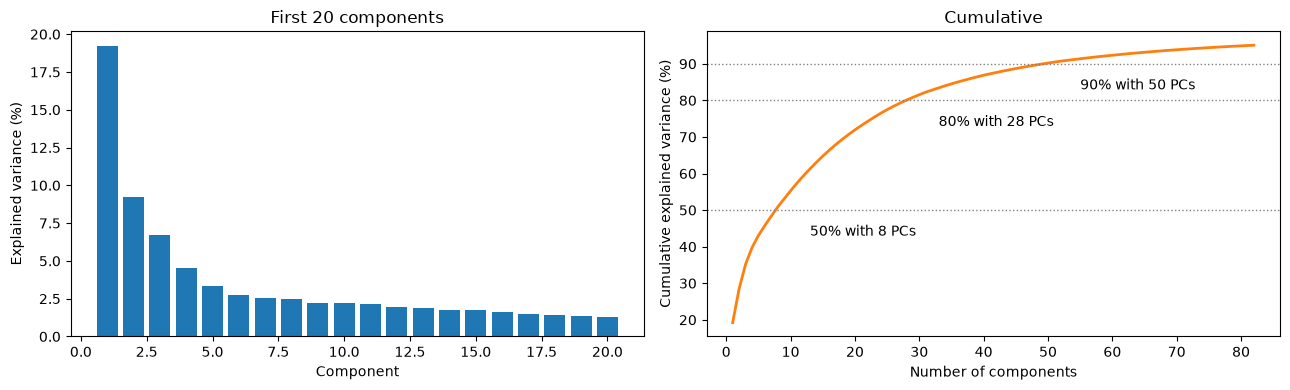

In [8]:
n = np.arange(1, pca.pca.n_components_ + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), tight_layout=True)
axes[0].bar(n[:20], pca.explained_variance_ratio[:20] * 100, color="C0")
axes[0].set(xlabel="Component", ylabel="Explained variance (%)", title="First 20 components")
axes[1].plot(n, pca.cumulative_explained_variance_ratio * 100, color="C1", linewidth=2)
for threshold in [50, 80, 90]:
    k = np.argmax(pca.cumulative_explained_variance_ratio * 100 >= threshold) + 1
    axes[1].axhline(threshold, color="grey", linestyle=":", linewidth=1)
    axes[1].annotate(f"{threshold}% with {k} PCs", (k, threshold), xytext=(k + 5, threshold - 7))
axes[1].set(xlabel="Number of components", ylabel="Cumulative explained variance (%)", title="Cumulative")

## 4. Reconstruct a daily field

Each day is now described only by its PC values. `inverse_transform` goes back from those values to a full pressure map. Comparing it with the original shows how much is lost with the retained components.

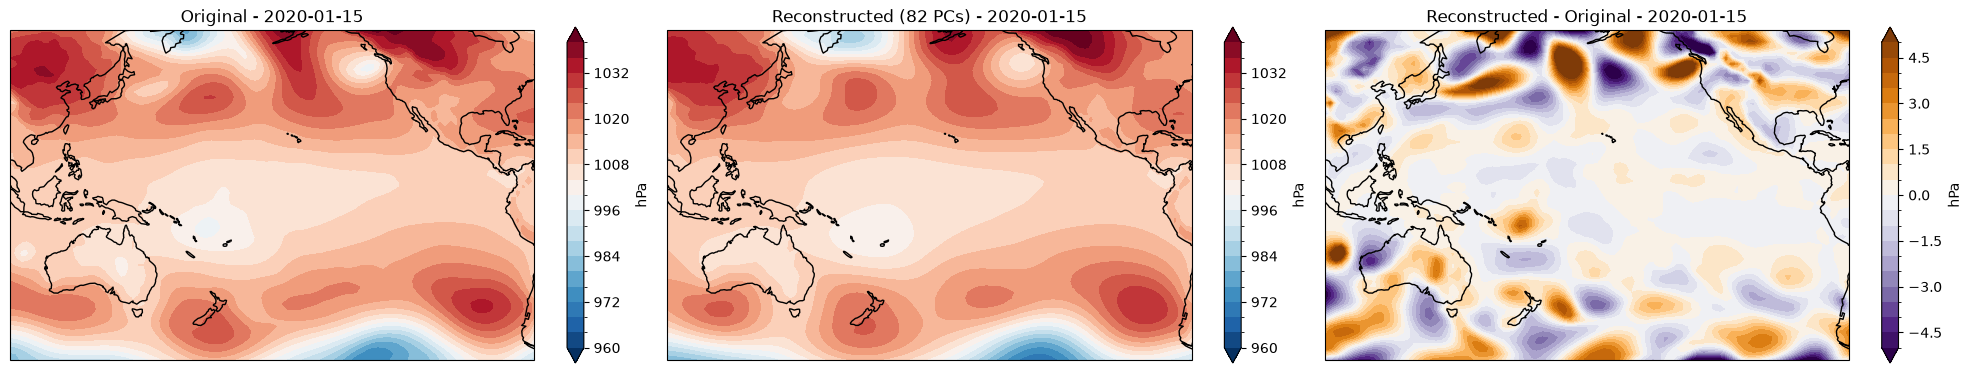

In [9]:
reconstructed = pca.inverse_transform(PCs=pcs.sel(time=[date])).msl.squeeze()
original = msl.sel(time=date)

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5), subplot_kw={"projection": proj}, tight_layout=True)
panels = [
    (original, "Original", levels, "RdBu_r"),
    (reconstructed, f"Reconstructed ({pca.pca.n_components_} PCs)", levels, "RdBu_r"),
    (reconstructed - original, "Reconstructed - Original", np.arange(-5, 5.5, 0.5), "PuOr_r"),
]
for ax, (field, title, lev, cmap) in zip(axes, panels):
    field.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(), levels=lev, cmap=cmap, extend="both",
        cbar_kwargs={"label": "hPa", "shrink": 0.8},
    )
    ax.coastlines()
    ax.set_title(f"{title} - {date}")

## 5. Spatial modes (EOFs)

The EOFs are the spatial patterns: the "new axes" onto which each daily map is projected. Their sign is arbitrary; what matters is the pattern and how it pairs with its PC.

- **EOF 1** shows opposite signs in the two hemispheres: it is the **seasonal cycle**, pressure rising in one hemisphere's winter while it falls in the other.
- **EOF 2** is dominated by a band of the same sign over the tropics and subtropics, opposed to the North Pacific: changes in the strength of the subtropical highs relative to the mid-latitude lows.
- **EOF 3** shows an **east-west dipole** in the tropics and subtropics, with opposite signs over the western Pacific / Australia and the southeastern Pacific. This resembles the **Southern Oscillation**, the atmospheric part of El Niño (ENSO).

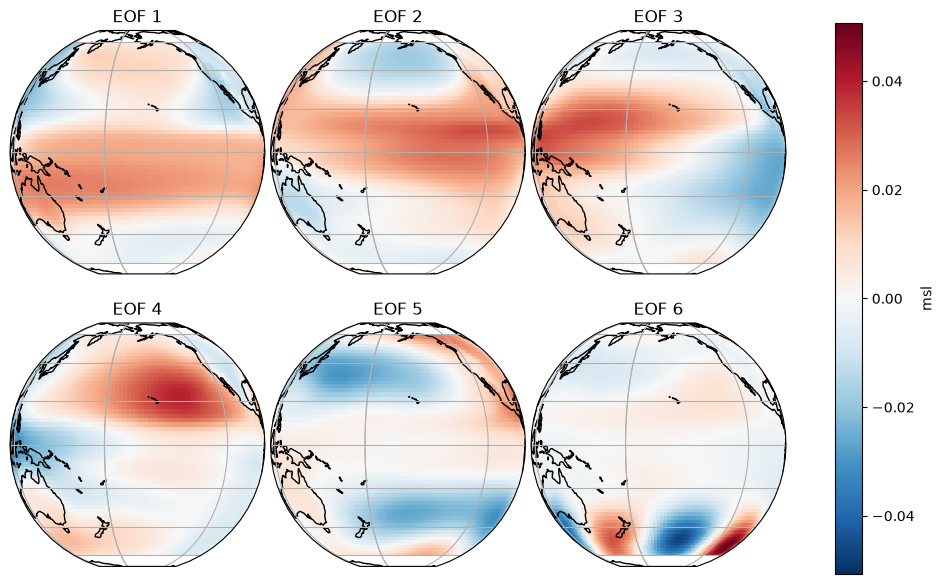

In [10]:
pca.plot_eofs(vars_to_plot=["msl"], num_eofs=6, map_center=(-165, 0))

## 6. Temporal indices (PCs)

The PCs are daily time series: how strongly each EOF is present on each day. They are the compact predictors used in the following notebooks.

The whole 1979–2025 record is shown in grey with a one-year rolling mean in color, and a zoom on a few years below. PC1 oscillates with a period of one year, confirming that it represents the seasonal cycle. PC3 changes more slowly, and its one-year rolling mean peaks in 1982–83, 1997–98 and 2015–16, the strongest El Niño events of the period, consistent with the ENSO-like pattern of EOF 3.

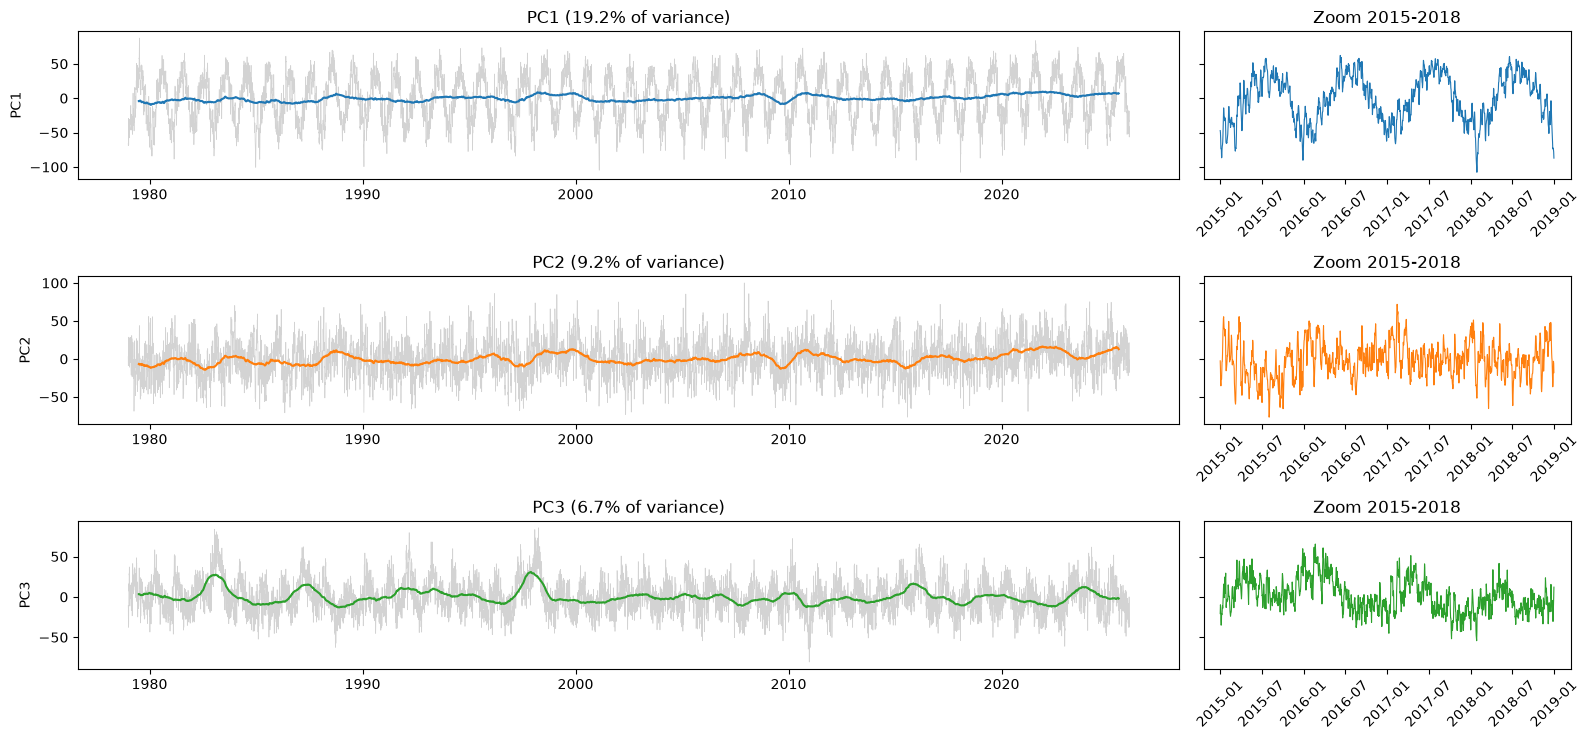

In [11]:
n_pcs = 3

fig, axes = plt.subplots(n_pcs, 2, figsize=(16, 2.5 * n_pcs), sharey="row", tight_layout=True,
                         gridspec_kw={"width_ratios": [3, 1]})
for i in range(n_pcs):
    pc = pcs.PCs.isel(n_component=i)
    ratio = pca.explained_variance_ratio[i]

    axes[i, 0].plot(pc.time, pc, color="lightgrey", linewidth=0.5)
    axes[i, 0].plot(pc.time, pc.rolling(time=365, center=True).mean(), color=f"C{i}", linewidth=1.5)
    axes[i, 0].set(ylabel=f"PC{i + 1}", title=f"PC{i + 1} ({ratio:.1%} of variance)")

    zoom = pc.sel(time=slice("2015", "2018"))
    axes[i, 1].plot(zoom.time, zoom, color=f"C{i}", linewidth=0.8)
    axes[i, 1].set(title="Zoom 2015-2018")
    axes[i, 1].tick_params(axis="x", labelrotation=45)

## 7. Adding the msl gradient

Pressure gradients drive wind, so we add a predictor of spatial pressure variation alongside msl. We compute it **after coarsening**, from the same 2° pressure fields used above, with [`bluemath_tk.core.operations.spatial_gradient`](https://geoocean.github.io/BlueMath_tk/_modules/bluemath_tk/core/operations.html#spatial_gradient). The input is a `DataArray` ordered as (`time`, `latitude`, `longitude`).

The published implementation sums squared neighboring pressure differences, with a cosine correction for longitude differences, and leaves the outermost grid cells at zero. It does not take a square root or divide by grid spacing in physical distance. Here `msl_gradient` therefore represents a **squared pressure-difference predictor**, in **hPa²** for our hPa input, rather than a gradient magnitude in hPa/km. We correct its metadata because the function assigns a fixed unit label unrelated to the input pressure units. The zero-valued boundary is an implementation convention, not an observed absence of pressure variation.


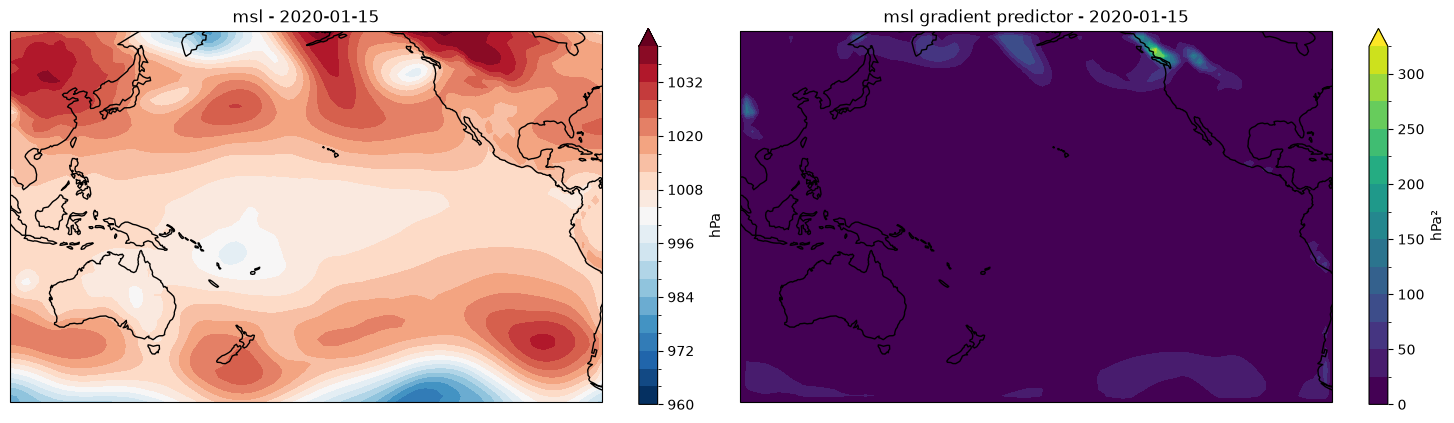

In [12]:
era5["msl_gradient"] = spatial_gradient(msl)
era5["msl_gradient"].attrs = {
    "long_name": "Squared spatial pressure-difference predictor",
    "units": "hPa^2",
    "description": "BlueMath spatial_gradient on the coarsened hPa field; zero outer boundary",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={"projection": proj}, tight_layout=True)
era5.msl.sel(time=date).plot.contourf(ax=axes[0], transform=ccrs.PlateCarree(), levels=levels, cmap="RdBu_r",
                                      cbar_kwargs={"label": "hPa", "shrink": 0.8})
era5.msl_gradient.sel(time=date).plot.contourf(ax=axes[1], transform=ccrs.PlateCarree(), levels=16, cmap="viridis", extend="max",
                                               cbar_kwargs={"label": "hPa²", "shrink": 0.8})
for ax, title in zip(axes, ["msl", "msl gradient predictor"]):
    ax.coastlines()
    ax.set_title(f"{title} - {date}")

Pressure fields over high terrain can contain artifacts from reducing pressure to sea level. Interpret the predictor primarily over the ocean, where waves are generated.

Both variables are now stacked, as in the `X` / `Y` example of the theory notebook. The default standardization (`scale_data=True`) accounts for their different scales.

The gradient predictor emphasizes local spatial variation and can require more components to explain a given fraction of variance. We fit **20 components** here and compare their explained variance with the pressure-only PCA. These percentages refer to two different feature sets.


In [13]:
pca_grad = PCA(n_components=20)
pcs_grad = pca_grad.fit_transform(
    data=era5,
    vars_to_stack=["msl", "msl_gradient"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)

k = 20
print(f"First {k} PCs - msl only:           {pca.cumulative_explained_variance_ratio[k - 1]:.1%} of the variance")
print(f"First {k} PCs - msl + msl gradient: {pca_grad.cumulative_explained_variance_ratio[k - 1]:.1%} of the variance")

First 20 PCs - msl only:           71.9% of the variance
First 20 PCs - msl + msl gradient: 45.6% of the variance


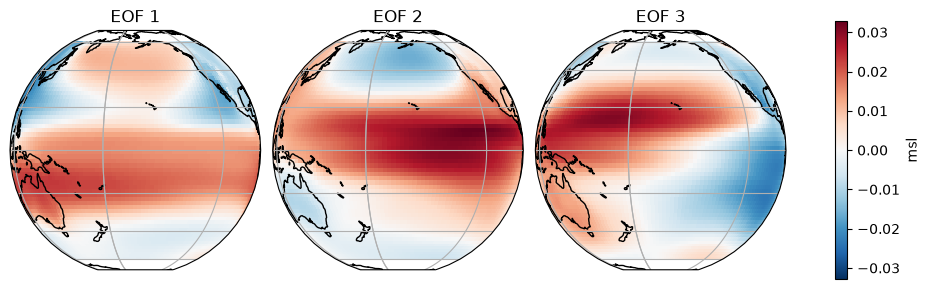

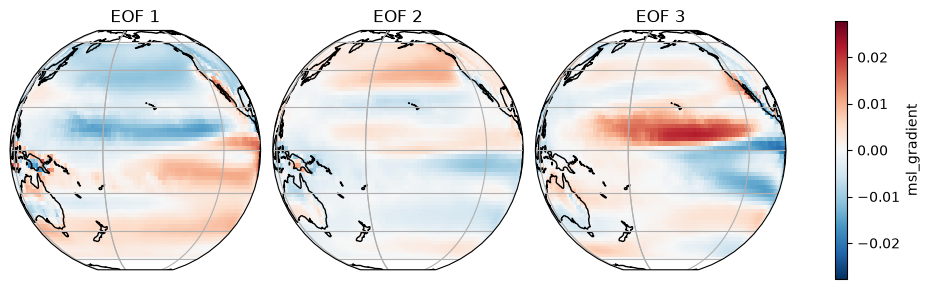

In [14]:
pca_grad.plot_eofs(vars_to_plot=["msl", "msl_gradient"], num_eofs=3, map_center=(-165, 0))

## Summary

- Daily ERA5 msl over the Pacific is selected for 1979–2025 and averaged from 0.25° to 2° with `coarsen`: roughly 17,000 days × 5,700 grid points.
- The reduced cache stores Pa; pressure is converted to hPa in memory.
- PCA retains 95% of the pressure variance, and `inverse_transform` reconstructs daily fields from the retained PCs.
- EOF maps and PC time series help interpret the main circulation patterns.
- `spatial_gradient` adds a squared pressure-difference predictor computed on the coarsened grid; a second PCA combines it with msl.

These PCs can then be used to relate large-scale atmospheric circulation to local variables such as waves.
